In [486]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [487]:
df = pd.read_csv('messy_customer_data.csv')

In [488]:
df.shape

(10000, 12)

In [489]:
df.head()

,CustomerID,Name,Gender,Age,City,Signup_Date,Last_purchase_date,purchase_amount,feedback_score,email,Phone_number,Country
0,NaN,Ankit,F,36,Mumbai,31/12/2024,13/08/2025,-999.0,2.0,NaN,0,Canada
1,C2,Ravi,Female,NaN,Kolkata,NaN,NaN,NaN,-1.0,user1mail.com,abc123,Canada
2,3,Ravi,female,66,Ahmedabad,NaN,20/06/2023,NaN,10.0,user2@mail.com,abc123,India
3,C4,Ankit,male,44,Kolkata,NaN,13/09/2025,NaN,NaN,NaN,9316267914,USA
4,5,Rahul,Male,200,Ahmedabad,9/7/25,NaN,-999.0,NaN,user4mail.com,9234603292,USA


In [490]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          7621 non-null   object 
 1   Name                8342 non-null   object 
 2   Gender              7545 non-null   object 
 3   Age                 7425 non-null   object 
 4   City                8870 non-null   object 
 5   Signup_Date         7471 non-null   object 
 6   Last_purchase_date  6714 non-null   object 
 7   purchase_amount     4967 non-null   float64
 8   feedback_score      7538 non-null   float64
 9   email               4934 non-null   object 
 10  Phone_number        7556 non-null   object 
 11  Country             8296 non-null   object 
dtypes: float64(2), object(10)
memory usage: 937.6+ KB


In [491]:
df.isnull().sum()/len(df)*100

CustomerID            23.79
Name                  16.58
Gender                24.55
Age                   25.75
City                  11.30
Signup_Date           25.29
Last_purchase_date    32.86
purchase_amount       50.33
feedback_score        24.62
email                 50.66
Phone_number          24.44
Country               17.04
dtype: float64

In [492]:
df[df.duplicated()].shape

(0, 12)

In [493]:
numerical_features = df.select_dtypes(include=[np.number])
categorical_features = df.select_dtypes(include=['object', 'category'])

### Step 1 - Handling Missing values

In [494]:
for col in df.columns:
    print(f"Column name {col}")
    print(f"Count: {df[col].nunique()}")
    print(f"{col}: {df[col].unique()}")
    print("=" * 50) 

Column name CustomerID
Count: 7621
CustomerID: [nan 'C2' '3' ... '9996' '9998' '10000']
Column name Name
Count: 10
Name: ['Ankit' 'Ravi' 'Rahul' 'Amit' 'Kiran' 'Simran' nan 'Pooja' 'Priya'
 'Sneha' 'Neha']
Column name Gender
Count: 6
Gender: ['F' 'Female' 'female' 'male' 'Male' nan 'M']
Column name Age
Count: 58
Age: ['36' nan '66' '44' '200' '64' '23  years' '24' '-5' '62' '30' '38' '26'
 '47' '21' '42' '50' '67' '22' '52' '57' '59' '23' '68' '51' '53' '43'
 '70' '33' '46' '39' '29' '28' '35 years' '35' '37' '18' '58' 'nan years'
 '65' '45' '31' '69' '20' '40' '61' '41' '54' '48' '19' '25' '49' '63'
 '56' '60' '34' '55' '32' '27']
Column name City
Count: 10
City: ['Mumbai' 'Kolkata' 'Ahmedabad' 'pune' 'Delhi' 'Pune' 'Chennai'
 'Hyderabad' 'Bangalore' 'Mum' nan]
Column name Signup_Date
Count: 1842
Signup_Date: ['31/12/2024' nan '9/7/25' ... '20/02/2022' '9/2/24' '24/05/2022']
Column name Last_purchase_date
Count: 1630
Last_purchase_date: ['13/08/2025' nan '20/06/2023' ... '23/10/2021' 

In [495]:
df['CustomerID'].value_counts().head(10)

CustomerID
C2       1
6668     1
C6682    1
6681     1
C6678    1
C6677    1
6676     1
6675     1
6674     1
6673     1
Name: count, dtype: int64

In [496]:
# Drop the column
## df.drop(columns=['customer_id'], inplace=True)

In [497]:
df.shape

(10000, 12)

In [498]:
df.describe().round()

,purchase_amount,feedback_score
count,4967.0,7538.0
mean,714.0,4.0
std,2002.0,5.0
min,-999.0,-1.0
25%,-999.0,-1.0
50%,-999.0,3.0
75%,2438.0,10.0
max,4999.0,10.0


In [499]:
for col in df.columns:
    if df[col].nunique() < 20:
        print(df[col].value_counts())
        print("==" * 50)

Name
Rahul     876
Sneha     870
Kiran     868
Ankit     845
Priya     831
Ravi      828
Neha      813
Amit      809
Simran    801
Pooja     801
Name: count, dtype: int64
Gender
Male      1325
female    1270
F         1262
M         1249
male      1226
Female    1213
Name: count, dtype: int64
City
Hyderabad    1144
Mumbai       1132
Pune         1129
Bangalore    1120
Chennai      1109
Delhi        1091
Ahmedabad    1087
Kolkata      1056
pune            1
Mum             1
Name: count, dtype: int64
feedback_score
 10.0    2521
-1.0     2489
 3.0      556
 1.0      532
 5.0      522
 2.0      495
 4.0      423
Name: count, dtype: int64
Country
USA          1679
Australia    1660
Canada       1658
UK           1658
India        1641
Name: count, dtype: int64


In [500]:
df['Name'].value_counts()

Name
Rahul     876
Sneha     870
Kiran     868
Ankit     845
Priya     831
Ravi      828
Neha      813
Amit      809
Simran    801
Pooja     801
Name: count, dtype: int64

In [501]:
df['Age'].unique()

array(['36', nan, '66', '44', '200', '64', '23  years', '24', '-5', '62',
       '30', '38', '26', '47', '21', '42', '50', '67', '22', '52', '57',
       '59', '23', '68', '51', '53', '43', '70', '33', '46', '39', '29',
       '28', '35 years', '35', '37', '18', '58', 'nan years', '65', '45',
       '31', '69', '20', '40', '61', '41', '54', '48', '19', '25', '49',
       '63', '56', '60', '34', '55', '32', '27'], dtype=object)

In [502]:
str('20 years')

'20 years'

In [503]:
import re

def extract_age(age):
    age_num = re.findall('[0-9]+', str(age))
    if len(age_num) > 0:
        return age_num[0]
    else:
        return age

In [504]:
df['Age'] = df['Age'].apply(lambda x: extract_age(x))

In [505]:
df['Age'].unique()

array(['36', nan, '66', '44', '200', '64', '23', '24', '5', '62', '30',
       '38', '26', '47', '21', '42', '50', '67', '22', '52', '57', '59',
       '68', '51', '53', '43', '70', '33', '46', '39', '29', '28', '35',
       '37', '18', '58', 'nan years', '65', '45', '31', '69', '20', '40',
       '61', '41', '54', '48', '19', '25', '49', '63', '56', '60', '34',
       '55', '32', '27'], dtype=object)

In [506]:
df_age = df[df['Age'] != 'nan years']['Age']

In [507]:
df_age.unique()

array(['36', nan, '66', '44', '200', '64', '23', '24', '5', '62', '30',
       '38', '26', '47', '21', '42', '50', '67', '22', '52', '57', '59',
       '68', '51', '53', '43', '70', '33', '46', '39', '29', '28', '35',
       '37', '18', '58', '65', '45', '31', '69', '20', '40', '61', '41',
       '54', '48', '19', '25', '49', '63', '56', '60', '34', '55', '32',
       '27'], dtype=object)

In [508]:
age_median = int(df_age.dropna().astype('int64').median())

In [509]:
age_median

43

In [510]:
df['Age'].replace('nan years', age_median, inplace=True)

In [511]:
df['Age'].fillna(age_median, inplace=True)

In [512]:
df.isnull().sum()/len(df)*100

CustomerID            23.79
Name                  16.58
Gender                24.55
Age                    0.00
City                  11.30
Signup_Date           25.29
Last_purchase_date    32.86
purchase_amount       50.33
feedback_score        24.62
email                 50.66
Phone_number          24.44
Country               17.04
dtype: float64

In [513]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          7621 non-null   object 
 1   Name                8342 non-null   object 
 2   Gender              7545 non-null   object 
 3   Age                 10000 non-null  object 
 4   City                8870 non-null   object 
 5   Signup_Date         7471 non-null   object 
 6   Last_purchase_date  6714 non-null   object 
 7   purchase_amount     4967 non-null   float64
 8   feedback_score      7538 non-null   float64
 9   email               4934 non-null   object 
 10  Phone_number        7556 non-null   object 
 11  Country             8296 non-null   object 
dtypes: float64(2), object(10)
memory usage: 937.6+ KB


In [514]:
df['purchase_amount'].fillna(df['purchase_amount'].median(), inplace=True) 

In [515]:
df.isnull().sum()/len(df)*100

CustomerID            23.79
Name                  16.58
Gender                24.55
Age                    0.00
City                  11.30
Signup_Date           25.29
Last_purchase_date    32.86
purchase_amount        0.00
feedback_score        24.62
email                 50.66
Phone_number          24.44
Country               17.04
dtype: float64

In [516]:
df['feedback_score'].value_counts()

feedback_score
 10.0    2521
-1.0     2489
 3.0      556
 1.0      532
 5.0      522
 2.0      495
 4.0      423
Name: count, dtype: int64

In [517]:
df['feedback_score'].fillna(df['feedback_score'].mode()[0], inplace=True)

In [518]:
df.isnull().sum()

CustomerID            2379
Name                  1658
Gender                2455
Age                      0
City                  1130
Signup_Date           2529
Last_purchase_date    3286
purchase_amount          0
feedback_score           0
email                 5066
Phone_number          2444
Country               1704
dtype: int64

In [519]:
df['City'].unique()

array(['Mumbai', 'Kolkata', 'Ahmedabad', 'pune', 'Delhi', 'Pune',
       'Chennai', 'Hyderabad', 'Bangalore', 'Mum', nan], dtype=object)

In [520]:
for col in ['Name', 'Gender', 'City', 'Country']:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [521]:
## Email has more than 50% missing value.
df.drop(columns=['email'], inplace=True)

In [522]:
## Phone_number might carry some predictive signal. Hence Fill with placeholder

df['Phone_number'].fillna('UNKNOWN', inplace=True)

In [523]:
df.isnull().sum()

CustomerID            2379
Name                     0
Gender                   0
Age                      0
City                     0
Signup_Date           2529
Last_purchase_date    3286
purchase_amount          0
feedback_score           0
Phone_number             0
Country                  0
dtype: int64

In [524]:
### Step 3 Incosistent formatting - 
df['Gender'].unique()

array(['F', 'Female', 'female', 'male', 'Male', 'M'], dtype=object)

In [525]:
df['Gender'] = df['Gender'].str.lower()

In [526]:
df['Gender'].replace({'m':'male', 'f':'female'}, inplace=True)

In [527]:
df['Country'].unique()

array(['Canada', 'India', 'USA', 'UK', 'Australia'], dtype=object)

In [528]:
df['City'].unique()

array(['Mumbai', 'Kolkata', 'Ahmedabad', 'pune', 'Delhi', 'Pune',
       'Chennai', 'Hyderabad', 'Bangalore', 'Mum'], dtype=object)

In [529]:
df['City'] = df['City'].str.lower().str.strip()

In [530]:
df['City'].replace({'mum':'mumbai'}, inplace=True)

In [531]:
df[df.duplicated()].shape

(0, 11)

In [532]:
df.shape

(10000, 11)

In [533]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          7621 non-null   object 
 1   Name                10000 non-null  object 
 2   Gender              10000 non-null  object 
 3   Age                 10000 non-null  object 
 4   City                10000 non-null  object 
 5   Signup_Date         7471 non-null   object 
 6   Last_purchase_date  6714 non-null   object 
 7   purchase_amount     10000 non-null  float64
 8   feedback_score      10000 non-null  float64
 9   Phone_number        10000 non-null  object 
 10  Country             10000 non-null  object 
dtypes: float64(2), object(9)
memory usage: 859.5+ KB


In [534]:
df.isnull().sum()

CustomerID            2379
Name                     0
Gender                   0
Age                      0
City                     0
Signup_Date           2529
Last_purchase_date    3286
purchase_amount          0
feedback_score           0
Phone_number             0
Country                  0
dtype: int64

In [535]:
## Droping CustomerID as it has zero predictive power — it can't generalize to unseen data 
df.drop(columns=['CustomerID'], inplace= True)

In [536]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                10000 non-null  object 
 1   Gender              10000 non-null  object 
 2   Age                 10000 non-null  object 
 3   City                10000 non-null  object 
 4   Signup_Date         7471 non-null   object 
 5   Last_purchase_date  6714 non-null   object 
 6   purchase_amount     10000 non-null  float64
 7   feedback_score      10000 non-null  float64
 8   Phone_number        10000 non-null  object 
 9   Country             10000 non-null  object 
dtypes: float64(2), object(8)
memory usage: 781.4+ KB


In [ ]:
df['Age'] = df['Age'].astype('int64')

In [538]:
missing_dates = df['Signup_Date'].isnull().sum()
missing_pct = df['Signup_Date'].isnull().mean() * 100
print(f"Invalid/Missing dates: {missing_dates} ({missing_pct:.1f}%)")

Invalid/Missing dates: 2529 (25.3%)


In [539]:

# Check data type and sample values
print(df['Signup_Date'].dtype)
print(df['Signup_Date'].head(10))

# Confirm zero missing values
print(f"Missing values: {df['Signup_Date'].isnull().sum()}")

object
0    31/12/2024
1           NaN
2           NaN
3           NaN
4        9/7/25
5    not_a_date
6    not_a_date
7           NaN
8    not_a_date
9    18/12/2023
Name: Signup_Date, dtype: object
Missing values: 2529


In [540]:
df['Signup_Date'].unique()

array(['31/12/2024', nan, '9/7/25', ..., '20/02/2022', '9/2/24',
       '24/05/2022'], dtype=object)

In [541]:
df.shape

(10000, 10)

In [542]:
df['Signup_Date'] = pd.to_datetime(df['Signup_Date'], format='mixed', dayfirst=True, errors='coerce')

# Verify conversion
print(df['Signup_Date'].dtype)   # Should be datetime64
print(df['Signup_Date'].head())

datetime64[ns]
0   2024-12-31
1          NaT
2          NaT
3          NaT
4   2025-07-09
Name: Signup_Date, dtype: datetime64[ns]


In [543]:
df['Signup_Date'].ffill(inplace=True)

In [544]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                10000 non-null  object        
 1   Gender              10000 non-null  object        
 2   Age                 10000 non-null  object        
 3   City                10000 non-null  object        
 4   Signup_Date         10000 non-null  datetime64[ns]
 5   Last_purchase_date  6714 non-null   object        
 6   purchase_amount     10000 non-null  float64       
 7   feedback_score      10000 non-null  float64       
 8   Phone_number        10000 non-null  object        
 9   Country             10000 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(7)
memory usage: 781.4+ KB


In [545]:
df['Last_purchase_date'] = pd.to_datetime(df['Last_purchase_date'], format='mixed', dayfirst=True, errors='coerce')

# Verify conversion
print(df['Last_purchase_date'].dtype)   # Should be datetime64
print(df['Last_purchase_date'].head())

datetime64[ns]
0   2025-08-13
1          NaT
2   2023-06-20
3   2025-09-13
4          NaT
Name: Last_purchase_date, dtype: datetime64[ns]


In [546]:
df['Last_purchase_date'].ffill(inplace=True)

In [552]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                10000 non-null  object        
 1   Gender              10000 non-null  object        
 2   Age                 10000 non-null  int64         
 3   City                10000 non-null  object        
 4   Signup_Date         10000 non-null  datetime64[ns]
 5   Last_purchase_date  10000 non-null  datetime64[ns]
 6   purchase_amount     10000 non-null  float64       
 7   feedback_score      10000 non-null  float64       
 8   Phone_number        10000 non-null  object        
 9   Country             10000 non-null  object        
dtypes: datetime64[ns](2), float64(2), int64(1), object(5)
memory usage: 781.4+ KB


In [548]:
df.isnull().sum()

Name                  0
Gender                0
Age                   0
City                  0
Signup_Date           0
Last_purchase_date    0
purchase_amount       0
feedback_score        0
Phone_number          0
Country               0
dtype: int64

In [549]:
df.shape

(10000, 10)

In [553]:
df.describe()

,Age,Signup_Date,Last_purchase_date,purchase_amount,feedback_score
count,10000.000000,10000,10000,10000.000000,10000.000000
mean,72.161500,2023-05-04 14:34:39.359999744,2023-05-03 16:08:58.560000,-148.324754,5.483300
min,5.000000,2020-08-06 00:00:00,2020-08-06 00:00:00,-999.000000,-1.000000
25%,5.000000,2021-12-18 00:00:00,2022-01-02 00:00:00,-999.000000,1.000000
50%,43.000000,2023-05-11 12:00:00,2023-04-21 00:00:00,-999.000000,5.000000
75%,69.000000,2024-09-14 00:00:00,2024-09-08 00:00:00,-999.000000,10.000000
max,200.000000,2026-01-26 00:00:00,2026-01-25 00:00:00,4998.670000,10.000000
std,74.941727,NaN,NaN,1650.540369,4.769486


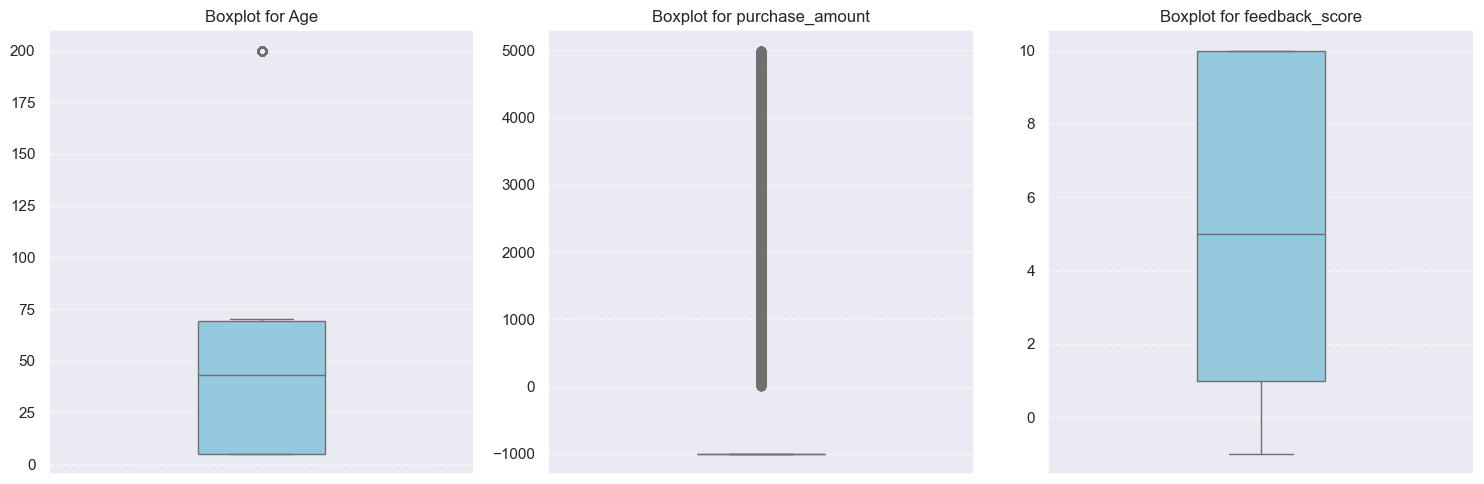

In [ ]:
cols = ['Age', 'purchase_amount', 'feedback_score']

plt.figure(figsize=(15, 5))
for i, col in enumerate(cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='skyblue', width=0.3) 
    plt.title(f'Boxplot for {col}', fontsize=12)
    plt.ylabel('')
    plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [562]:
from scipy import stats
z_scores = np.abs(stats.zscore(df[['Age', 'purchase_amount']]))

In [563]:
df_clean = df[~(z_scores > 3).any(axis=1)]

In [564]:
df_clean.shape

(9913, 10)